
 KASUS 1: DIAGNOSA DBD 
Input Data: Suhu=38.5°C, Trombosit=120, Leukosit=3.8
--- Fuzzifikasi ---
Suhu [Normal: 0, Demam: 0.50, Tinggi: 0.17]
Trombosit [Rendah: 1, Normal: 0]
Leukosit [Rendah: 1, Normal: 0]
--- Inferensi (Alpha Cut) ---
Risiko Rendah : 0.00
Risiko Sedang : 0.00
Risiko Tinggi : 0.50
--- Hasil Akhir ---
Score Defuzzifikasi (Centroid): 80.00
Kesimpulan: Risiko Tinggi


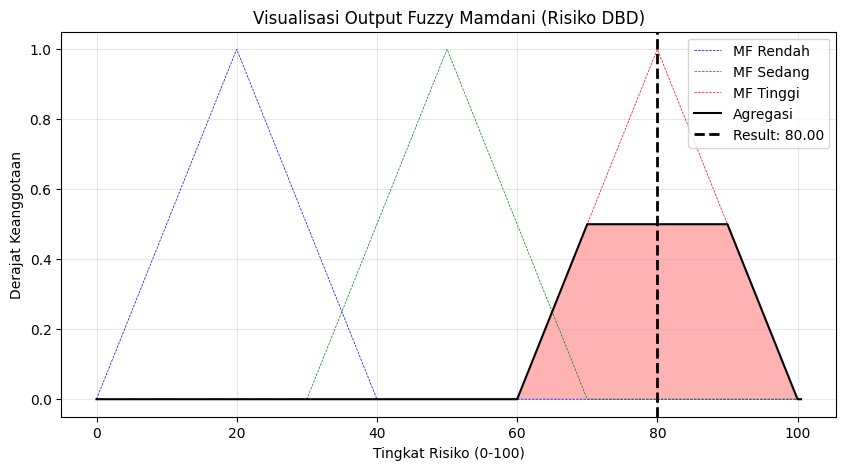


 KASUS 2: ANFIS AGROINDUSTRI 
Input: Soil Moisture=60%, Avg Temp=26°C
Weights -> w1:0.00, w2:0.00, w3:0.00, w4:0.44
Predicted Corn Production: 3.8580 ton/ha


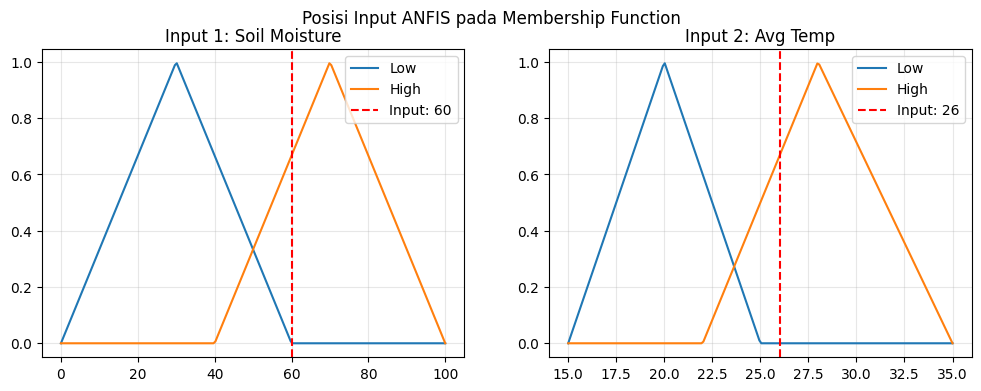

Generating 3D Surface Plot... (Mohon tunggu sebentar)


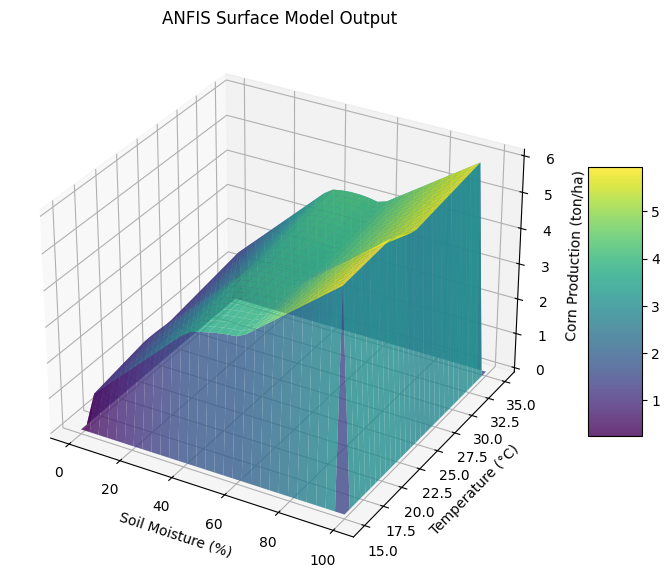

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ==========================================
# BAGIAN 1: FUZZY LOGIC (MAMDANI) + VISUALISASI
# ==========================================

class FuzzyDBD_Visual:
    def __init__(self):
        # Range output 0-100 dengan resolusi tinggi untuk plotting halus
        self.x_out = np.arange(0, 101, 0.5)

    # Fungsi Keanggotaan Segitiga (Versi NumPy support)
    def trimf(self, x, a, b, c):
        return np.maximum(0, np.minimum((x - a) / (b - a), (c - x) / (c - b)))

    # Fungsi Keanggotaan Trapesium
    def trapmf_right_high(self, x, a, b):
        return np.maximum(0, np.minimum(1, (x - a) / (b - a)))

    def calculate_and_plot(self, suhu, trombosit, leukosit):
        print(f"\n{'='*20}\n KASUS 1: DIAGNOSA DBD \n{'='*20}")
        print(f"Input Data: Suhu={suhu}°C, Trombosit={trombosit}, Leukosit={leukosit}")

        # --- 1. FUZZIFIKASI ---
        # Suhu
        t_normal = 1 if 36 <= suhu <= 37.5 else 0
        t_demam = float(self.trimf(suhu, 37, 38, 39))
        t_tinggi = float(self.trapmf_right_high(suhu, 38, 41))

        # Trombosit
        p_rendah = 1 if trombosit < 150 else 0
        p_normal = 1 if 150 <= trombosit <= 400 else 0

        # Leukosit
        l_rendah = 1 if leukosit < 4 else 0
        l_normal = 1 if 4 <= leukosit <= 10 else 0

        print(f"--- Fuzzifikasi ---")
        print(f"Suhu [Normal: {t_normal}, Demam: {t_demam:.2f}, Tinggi: {t_tinggi:.2f}]")
        print(f"Trombosit [Rendah: {p_rendah}, Normal: {p_normal}]")
        print(f"Leukosit [Rendah: {l_rendah}, Normal: {l_normal}]")

        # --- 2. INFERENSI ---
        r1 = min(t_tinggi, p_rendah, l_rendah) # Rule 1 -> Tinggi
        r2 = min(t_demam, p_rendah)            # Rule 2 -> Tinggi
        r3 = min(t_demam, p_normal)            # Rule 3 -> Sedang
        r4 = min(t_normal, p_normal, l_normal) # Rule 4 -> Rendah
        r5 = min(t_tinggi, l_normal)           # Rule 5 -> Sedang

        # Agregasi (Max)
        alpha_tinggi = max(r1, r2)
        alpha_sedang = max(r3, r5)
        alpha_rendah = r4

        print(f"--- Inferensi (Alpha Cut) ---")
        print(f"Risiko Rendah : {alpha_rendah:.2f}")
        print(f"Risiko Sedang : {alpha_sedang:.2f}")
        print(f"Risiko Tinggi : {alpha_tinggi:.2f}")

        # --- 3. DEFUZZIFIKASI & PERSIAPAN PLOTTING ---
        # Generate bentuk dasar himpunan output
        mf_rendah = self.trimf(self.x_out, 0, 20, 40)
        mf_sedang = self.trimf(self.x_out, 30, 50, 70)
        mf_tinggi = self.trimf(self.x_out, 60, 80, 100)

        # Potong kurva berdasarkan alpha (np.fmin = clipping)
        act_rendah = np.fmin(alpha_rendah, mf_rendah)
        act_sedang = np.fmin(alpha_sedang, mf_sedang)
        act_tinggi = np.fmin(alpha_tinggi, mf_tinggi)

        # Gabungkan semua area (Union / Max)
        aggregated = np.fmax(act_rendah, np.fmax(act_sedang, act_tinggi))

        # Hitung Centroid
        numerator = np.sum(self.x_out * aggregated)
        denominator = np.sum(aggregated)
        result = numerator / denominator if denominator != 0 else 0

        risk_label = "Rendah" if result < 40 else "Sedang" if result < 70 else "Tinggi"

        print(f"--- Hasil Akhir ---")
        print(f"Score Defuzzifikasi (Centroid): {result:.2f}")
        print(f"Kesimpulan: Risiko {risk_label}")

        # --- 4. VISUALISASI ---
        plt.figure(figsize=(10, 5))

        # Plot garis himpunan dasar (tipis, putus-putus)
        plt.plot(self.x_out, mf_rendah, 'b--', linewidth=0.5, label='MF Rendah')
        plt.plot(self.x_out, mf_sedang, 'g--', linewidth=0.5, label='MF Sedang')
        plt.plot(self.x_out, mf_tinggi, 'r--', linewidth=0.5, label='MF Tinggi')

        # Plot area yang terisi (Filled Area)
        plt.fill_between(self.x_out, np.zeros_like(self.x_out), act_rendah, facecolor='b', alpha=0.3)
        plt.fill_between(self.x_out, np.zeros_like(self.x_out), act_sedang, facecolor='g', alpha=0.3)
        plt.fill_between(self.x_out, np.zeros_like(self.x_out), act_tinggi, facecolor='r', alpha=0.3)

        # Plot garis contour agregasi (tebal hitam)
        plt.plot(self.x_out, aggregated, 'k', linewidth=1.5, label='Agregasi')

        # Garis Centroid
        plt.axvline(x=result, color='k', linestyle='--', linewidth=2, label=f'Result: {result:.2f}')

        plt.title('Visualisasi Output Fuzzy Mamdani (Risiko DBD)')
        plt.xlabel('Tingkat Risiko (0-100)')
        plt.ylabel('Derajat Keanggotaan')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

# ==========================================
# BAGIAN 2: ANFIS (SUGENO) + VISUALISASI
# ==========================================

class ANFISCorn_Visual:
    def trimf(self, x, a, b, c):
        # Support single scalar or numpy array
        return np.maximum(0, np.minimum((x - a) / (b - a), (c - x) / (c - b)))

    def predict_single(self, x1, x2, visual=True):
        if visual:
            print(f"\n{'='*20}\n KASUS 2: ANFIS AGROINDUSTRI \n{'='*20}")
            print(f"Input: Soil Moisture={x1}%, Avg Temp={x2}°C")

        # Layer 1: Fuzzifikasi
        mu_x1_low = float(self.trimf(x1, 0, 30, 60))
        mu_x1_high = float(self.trimf(x1, 40, 70, 100))

        mu_x2_low = float(self.trimf(x2, 15, 20, 25))
        mu_x2_high = float(self.trimf(x2, 22, 28, 35))

        # Layer 2: Weights
        w1 = mu_x1_low * mu_x2_low
        w2 = mu_x1_low * mu_x2_high
        w3 = mu_x1_high * mu_x2_low
        w4 = mu_x1_high * mu_x2_high
        total_w = w1 + w2 + w3 + w4

        if visual:
            print(f"Weights -> w1:{w1:.2f}, w2:{w2:.2f}, w3:{w3:.2f}, w4:{w4:.2f}")

        # Layer 3 & 4: Output Rules
        # y = px1 + qx2 + r
        f1 = (0.0692 * x1) + (0.0461 * x2) + 0.00231
        f2 = (0.0698 * x1) + (0.0390 * x2) + 0.00139
        f3 = (0.0585 * x1) + (0.0183 * x2) + 0.00084
        f4 = (0.0505 * x1) + (0.0318 * x2) + 0.00115

        # Weighted Average
        out1 = w1 * f1
        out2 = w2 * f2
        out3 = w3 * f3
        out4 = w4 * f4

        final_output = (out1 + out2 + out3 + out4) / total_w if total_w > 0 else 0

        if visual:
            print(f"Predicted Corn Production: {final_output:.4f} ton/ha")
            self.plot_inputs(x1, x2, mu_x1_low, mu_x1_high, mu_x2_low, mu_x2_high)

        return final_output

    def plot_inputs(self, x1_val, x2_val, m1l, m1h, m2l, m2h):
        # Setup Grid
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

        # Plot Input 1: Soil
        x_soil = np.linspace(0, 100, 200)
        ax1.plot(x_soil, self.trimf(x_soil, 0, 30, 60), label='Low')
        ax1.plot(x_soil, self.trimf(x_soil, 40, 70, 100), label='High')
        ax1.axvline(x=x1_val, color='r', linestyle='--', label=f'Input: {x1_val}')
        ax1.set_title('Input 1: Soil Moisture')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # Plot Input 2: Temp
        x_temp = np.linspace(15, 35, 200)
        ax2.plot(x_temp, self.trimf(x_temp, 15, 20, 25), label='Low')
        ax2.plot(x_temp, self.trimf(x_temp, 22, 28, 35), label='High')
        ax2.axvline(x=x2_val, color='r', linestyle='--', label=f'Input: {x2_val}')
        ax2.set_title('Input 2: Avg Temp')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        plt.suptitle("Posisi Input ANFIS pada Membership Function")
        plt.show()

    # Visualisasi Tambahan: 3D Surface Plot untuk Model
    def plot_surface(self):
        print("Generating 3D Surface Plot... (Mohon tunggu sebentar)")
        x1_range = np.linspace(0, 100, 30)
        x2_range = np.linspace(15, 35, 30)
        X1, X2 = np.meshgrid(x1_range, x2_range)
        Z = np.zeros_like(X1)

        for i in range(X1.shape[0]):
            for j in range(X1.shape[1]):
                # Panggil fungsi predict tanpa print log (visual=False)
                Z[i, j] = self.predict_single(X1[i, j], X2[i, j], visual=False)

        fig = plt.figure(figsize=(10, 7))
        ax = fig.add_subplot(111, projection='3d')
        surf = ax.plot_surface(X1, X2, Z, cmap='viridis', edgecolor='none', alpha=0.8)
        ax.set_xlabel('Soil Moisture (%)')
        ax.set_ylabel('Temperature (°C)')
        ax.set_zlabel('Corn Production (ton/ha)')
        ax.set_title('ANFIS Surface Model Output')
        fig.colorbar(surf, shrink=0.5, aspect=5)
        plt.show()

# ==========================================
# EKSEKUSI UTAMA
# ==========================================
if __name__ == "__main__":
    # 1. Jalankan Fuzzy Logic (DBD)
    dbd = FuzzyDBD_Visual()
    dbd.calculate_and_plot(suhu=38.5, trombosit=120, leukosit=3.8)

    # 2. Jalankan ANFIS (Jagung)
    corn = ANFISCorn_Visual()
    # Prediksi satu titik
    corn.predict_single(x1=60, x2=26)
    # Tampilkan model keseluruhan (3D)
    corn.plot_surface()